In [1]:
#导入必须库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams          #字体设置
import matplotlib.dates as mdates         #处理日期坐标轴
import seaborn as sns
from analyse_main import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

In [2]:
#导入数据
df = pd.read_csv(r'C:\Users\ASUS\Project\Project\data\猫眼电影.csv')

In [3]:
#清洗空值
pd.isna(df).sum()
df = df[df['pub_time'].str.len()>8]

In [4]:
#新数据特征构造
df['country'] = df['pub_time'].str.split('(',).str[1].str.split(')').str[0]
df['pub_time'] = df['pub_time'].str.split('(').str[0]
df['pub_time'] = pd.to_datetime(df['pub_time'])

In [5]:
#统计演员出现次数
authors_exploded = df['author'].str.split(',').explode()
author_count = authors_exploded.value_counts().reset_index()

In [6]:
#统计标签出现次数
style_exploded = df['style'].str.split(',').explode()
style_count = style_exploded.value_counts().reset_index()

In [7]:
#播放时长分段
labels = ['低时长','中时长','高时长','超高时长']
df['long_time_level'] = pd.cut(df['long_time'],
       bins = 4,
       labels = labels)

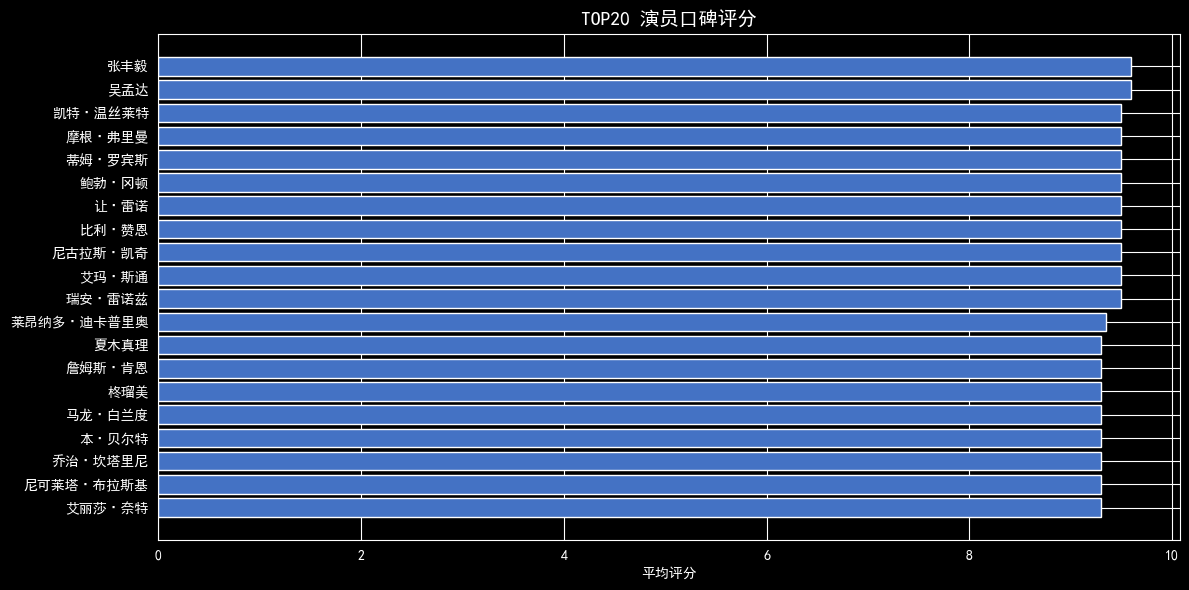

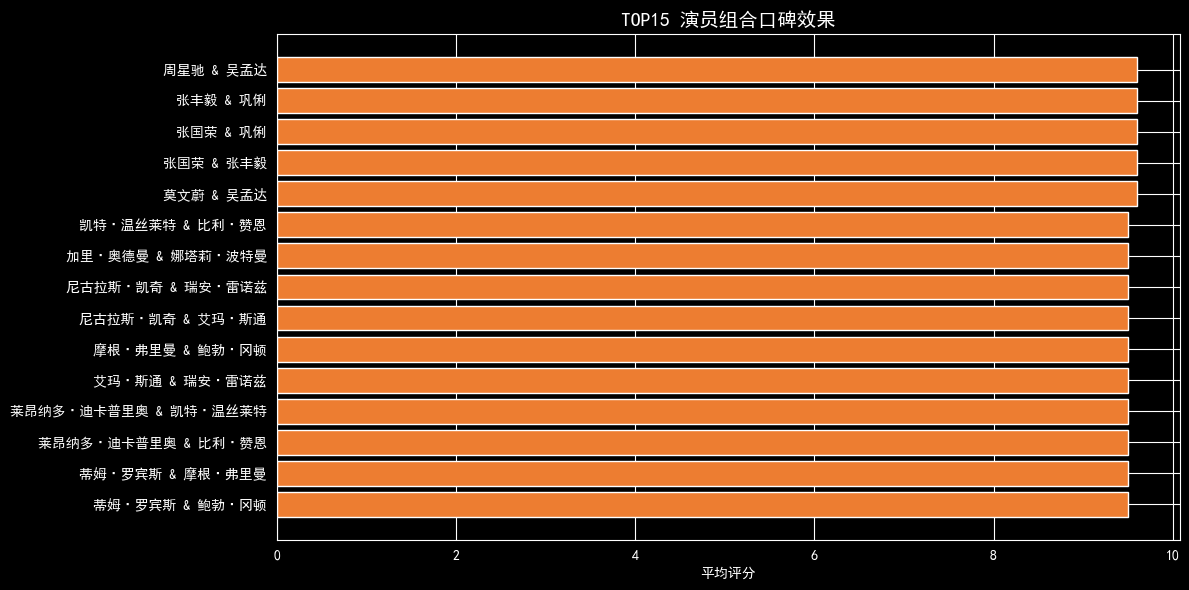

In [8]:
actor_rep = analyze_actor_reputation(df)
combo_top = analyze_actor_combination(df, top_n=15)

plot_top_actors(actor_rep)
plot_top_combinations(combo_top)

===== 风格口碑排行榜 =====
   style  movie_count  avg_star
20    灾难            1      9.50
14    历史            4      9.10
2     冒险           21      9.09
6     犯罪           13      9.09
7     动画           13      9.08
9     惊悚           11      9.07
5     喜剧           18      9.07
11    科幻            8      9.06
10    战争            8      9.05
17    歌舞            2      9.05
1     爱情           26      9.05
8     家庭           13      9.04
0     剧情           54      9.03
15    古装            4      9.02
3     动作           21      9.01
4     奇幻           19      9.00
16   纪录片            3      9.00
18    音乐            2      9.00
22    西部            1      8.90
13    传记            5      8.88

===== 风格组合效果Top15 =====
        pair  搭配次数  平均评分
5   (冒险, 喜剧)     1  9.60
28  (动作, 喜剧)     1  9.60
42  (历史, 灾难)     1  9.50
43  (历史, 爱情)     1  9.50
80  (爱情, 灾难)     1  9.50
69  (战争, 剧情)     1  9.30
88  (科幻, 动画)     1  9.30
89  (科幻, 惊悚)     1  9.30
70  (战争, 爱情)     2  9.25
73  (爱情, 古装)     2  9.20
12  (剧情,

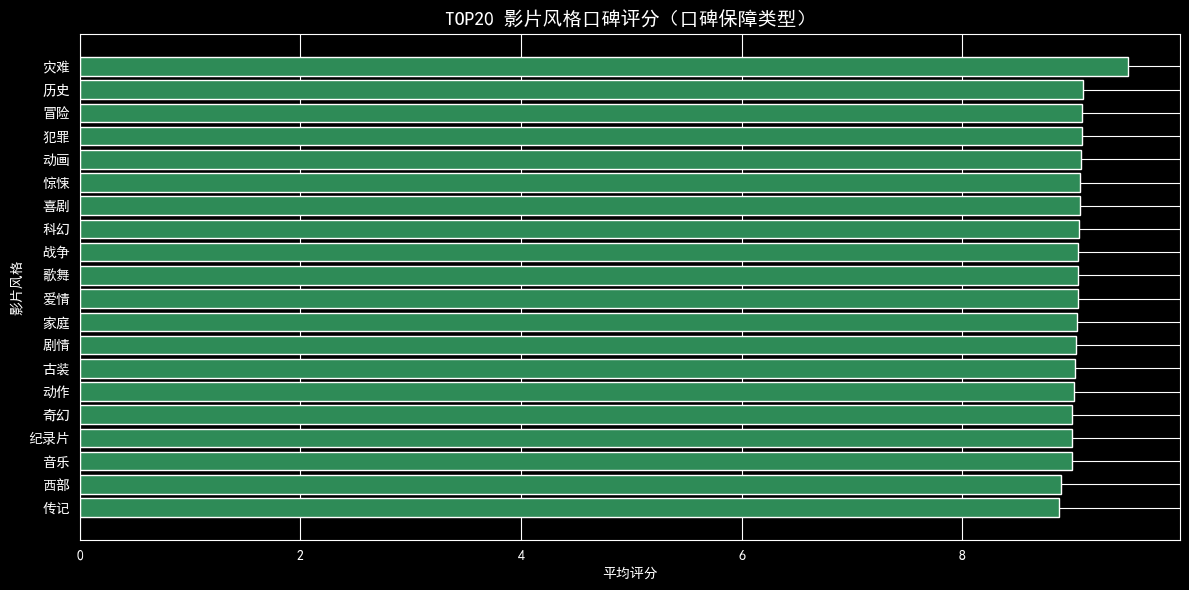

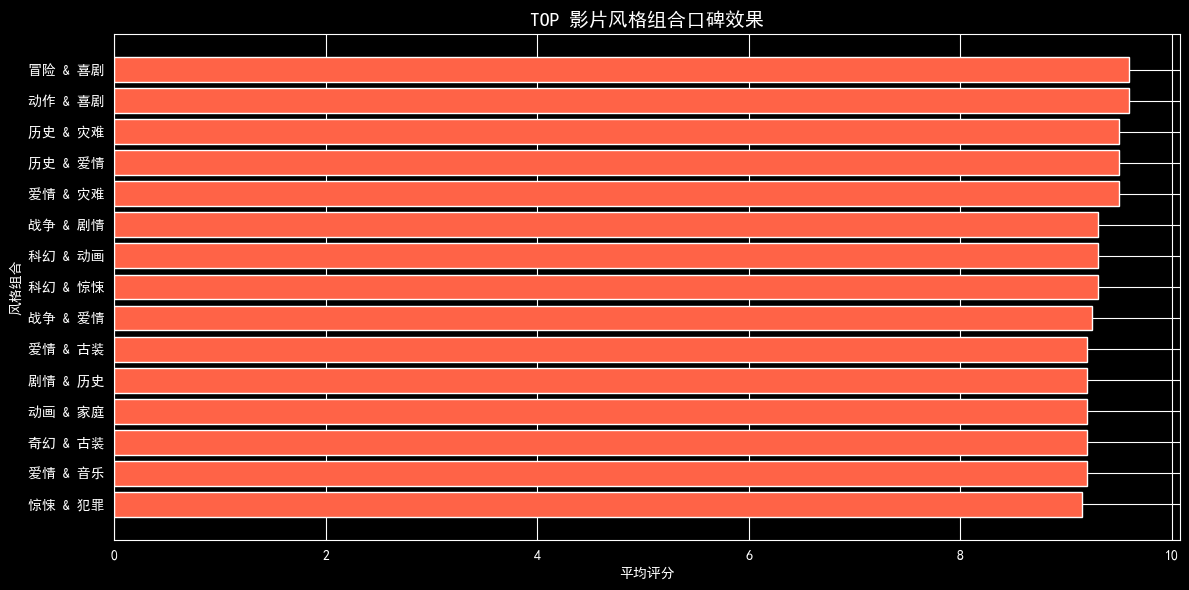

In [9]:
# 1. 风格口碑分析
style_rep = analyze_style_reputation(df)
print("===== 风格口碑排行榜 =====")
print(style_rep.head(20))

# 2. 风格组合分析
style_combo_top = analyze_style_combination(df, top_n=15)
print("\n===== 风格组合效果Top15 =====")
print(style_combo_top)

# 3. 画图
plot_top_styles(style_rep)
plot_top_style_combinations(style_combo_top)

In [10]:
df

,title,author,pub_time,star,style,long_time,country,long_time_level
0,霸王别姬,"张国荣,张丰毅,巩俐",1993-01-01,9.6,"爱情,剧情",171,NaN,高时长
1,肖申克的救赎,"蒂姆·罗宾斯,摩根·弗里曼,鲍勃·冈顿",1994-10-14,9.5,"犯罪,剧情",142,美国,高时长
2,罗马假日,"格利高里·派克,奥黛丽·赫本,埃迪·艾伯特",1953-09-02,9.1,"喜剧,剧情,爱情",118,美国,中时长
3,这个杀手不太冷,"让·雷诺,加里·奥德曼,娜塔莉·波特曼",1994-09-14,9.5,"剧情,惊悚,犯罪",110,法国,中时长
4,教父,"马龙·白兰度,阿尔·帕西诺,詹姆斯·肯恩",1972-03-24,9.3,"犯罪,剧情,惊悚",175,美国,高时长
5,泰坦尼克号,"莱昂纳多·迪卡普里奥,凯特·温丝莱特,比利·赞恩",1998-04-03,9.5,"历史,爱情,灾难",194,NaN,超高时长
6,唐伯虎点秋香,"周星驰,巩俐,郑佩佩",1993-07-01,9.2,"喜剧,爱情,古装",102,中国香港,中时长
7,千与千寻,"柊瑠美,入野自由,夏木真理",2001-07-20,9.3,"动画,奇幻,冒险",125,日本,中时长
8,魂断蓝桥,"费雯·丽,罗伯特·泰勒,露塞尔·沃特森",1940-05-17,9.2,"剧情,战争,爱情",108,美国,中时长
9,乱世佳人,"费雯·丽,克拉克·盖博,奥利维娅·德哈维兰",1939-12-15,9.1,"剧情,爱情,战争",238,美国,超高时长



===== 年代趋势数据 =====
       年代  影片数量      平均评分
0  1930年代     1  9.100000
1  1940年代     1  9.200000
2  1950年代     3  9.100000
3  1960年代     3  8.966667
4  1970年代     3  9.033333
5  1980年代     3  9.100000
6  1990年代    23  9.078261
7  2000年代    28  8.978571
8  2010年代    33  9.036364


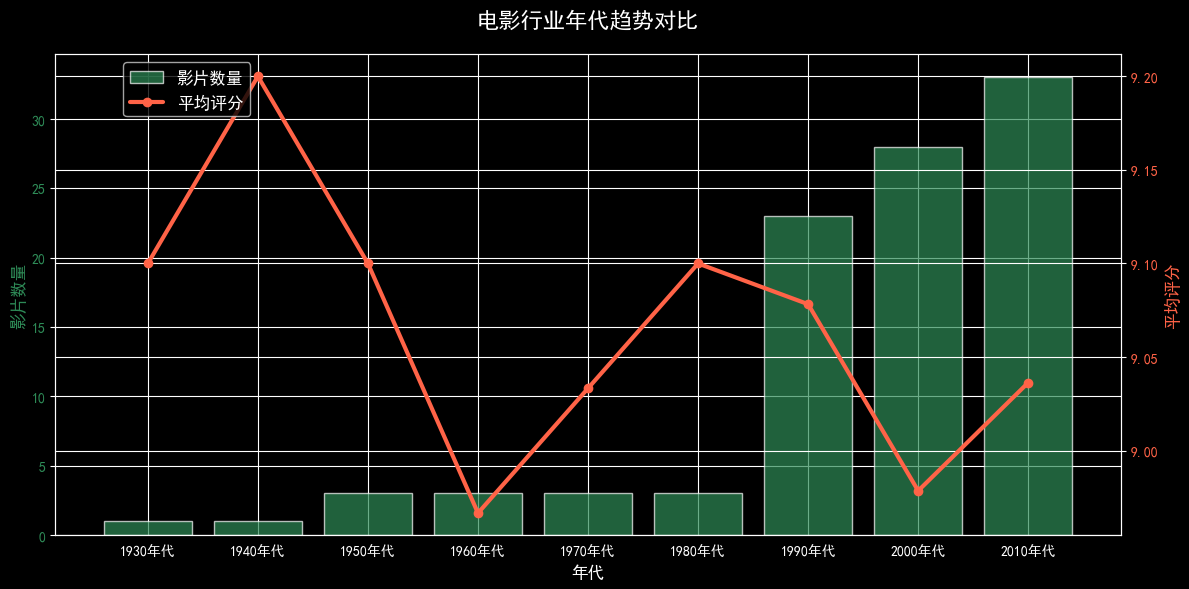

In [11]:
#年代趋势分析
decade_trend = analyze_decade_trend(df)
print("\n===== 年代趋势数据 =====")
print(decade_trend[['年代', '影片数量', '平均评分']])

#画图
plot_decade_trend(decade_trend)

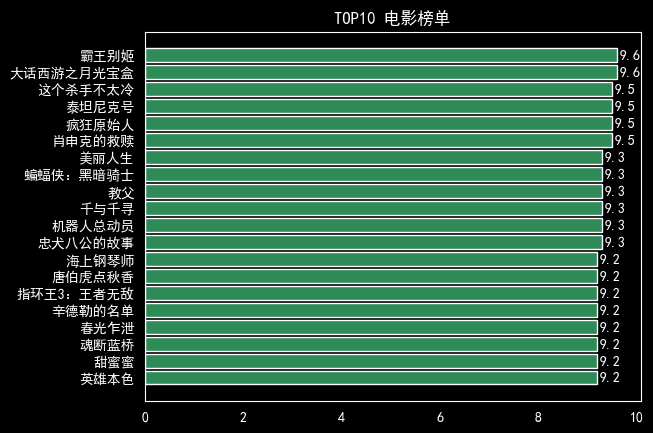

In [12]:
#电影top榜
top_movie(df)